# Análisis en Hábitos de Compra por Usuarios de Instacart

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.

En este proyecto se responderán a múltiples preguntas con diversos grados de dificultad y relacionadas a los hábitos de compra de los usuarios. La finalidad es que Instacart logre aprender más sobre sus usuarios para tener bases en la planificación de estretagias comerciales y de marketing que mejoren la rentabilidad.

**Diccionario de datos**

Hay cinco tablas en el conjunto de datos con el siguiente significado:

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

## Preprocesamiento de los datos

In [451]:
# Importar librerías
import pandas as pd
from matplotlib import pyplot as plt

In [452]:
# leer conjuntos de datos en los DataFrames
df_instacart_orders = pd.read_csv("../data/instacart_orders.csv", sep=";")
df_products = pd.read_csv("../data/products.csv", sep=";")
df_aisles = pd.read_csv("../data/aisles.csv", sep=";")
df_departments = pd.read_csv("../data/departments.csv", sep=";")
df_order_products = pd.read_csv("../data/order_products.csv", sep=";")

In [453]:
# Mostrar información del DataFrame
df_instacart_orders.info()
print('-' * 75)
df_products.info()
print('-' * 75)
df_aisles.info()
print('-' * 75)
df_departments.info()
print('-' * 75)
df_order_products.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
---------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null 

Observaciones:

1. En dataframe "df_instacart_orders" la columna `days_since_prior_order` es del tipo float, por la descripción en el diccionario de datos es casi seguro que se refiera a días enteros, posiblemente se deba transformar el tipo de la columna. Algo similar ocurre con `add_to_cart_order` del dataframe "df_order_products".
2. Para los dataframe "df_aisles" y "df_departments" los tipos de columnas se ven coherentes a su descripción y contamos con cero valores nulos cuando los demás dataframe sí tienen, esto ayudará en la limpieza de los datos.

Plan de acción:

1. Encontrar, revisar y eliminar los datos duplicados en cada df.
2. Descucrir los datos nulos, entender a qué se debe que estén ahí y tomar decisiones como eliminarlos o sustituirlos por otros datos coherentes.
3. Analizar si los tipos de de datos son los correctos o se deba realizar una transformación.

### Encontrar y eliminar valores duplicados

**Dataframe `instacart_orders`**

In [454]:
print("Las filas duplicadas de los pedidos son:", df_instacart_orders.duplicated().sum())
print()
print(df_instacart_orders[df_instacart_orders.duplicated(keep=False)].sort_values("order_id")) # Imprimo todos los duplicados para encontrar patrones.

Las filas duplicadas de los pedidos son: 15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
354993    391768    57671            19          3                  2   
371905    391768    57671            19          3                  2   
119251    408114    68324             4          3                  2   
321100    408114    68324             4          3                  2   
394347    467134    63189            21          3                  2   
250626    467134    63189            21          3                  2   
145574    794638    50898            24          3                  2   
99462     794638    50898            24          3                  2   
242618   1021560    53767             3          3                  2   
311713   1021560    53767             3          3                  2   
273805   1112182   202304            84          3                  2   
164581   1112182   202304            84          3                  2   
314427

Al ordenar el dataframe con los duplicados por distintas columnas, no noté algo especial además del que todos los pedidos se hicieron en el día 3 (miércoles) a las 2 a.m.

In [455]:
# Verificación de que todos los pedidos se hicieron el miércoles a las 2:00 a.m.
filtered_orders = df_instacart_orders.query("order_dow==3 and order_hour_of_day==2") # Realizo filtrado.
print(filtered_orders.sample(15)) # Uso sample para ver varias lineas aleatorias y observar patrones.

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
24691     690242    77357             2          3                  2   
443590    781491    51960             5          3                  2   
230807   1918001   188546            14          3                  2   
244432   1395560   166923             6          3                  2   
96232    1542137   136709            43          3                  2   
97378    3226444   149996             3          3                  2   
164581   1112182   202304            84          3                  2   
5156     2190225   138285            18          3                  2   
178949   2677202   134700             2          3                  2   
77051    2800415   196070             3          3                  2   
417106    248760   204961            25          3                  2   
223105   2160484   107525            16          3                  2   
395002   1090993    30945             5          3 

De las 121 líneas resultantes y después revisarlas ordenando por varias columnas, no noté algo anormal salvo los pedidos duplicados, por lo que considero se pueden eliminar sin afectar el dataframe.

In [456]:
# Eliminación los pedidos duplicados
df_instacart_orders = df_instacart_orders.drop_duplicates().reset_index(drop=True) # No está de más actualizar el índice.

In [457]:
print("Ahora las filas duplicadas de los pedidos son:", df_instacart_orders.duplicated().sum())

Ahora las filas duplicadas de los pedidos son: 0


In [458]:
print("Los IDs duplicados son:", df_instacart_orders.duplicated("order_id").sum())

Los IDs duplicados son: 0


Se detectaron las pedidos duplicados, estos tenían la característica de que se habían hecho en miércoles a las 2 a.m. Después de revisar todos los pedidos con estas dos características, no se encontró algo anormal, por lo que se dicidió eliminarlos.

**Dataframe `products`**

In [459]:
print("Las filas totalmente duplicadas del dataframe de los productos son:", df_products.duplicated().sum())

Las filas totalmente duplicadas del dataframe de los productos son: 0


In [460]:
print("Los IDs duplicados de los productos son:", df_products["product_id"].duplicated().sum())

Los IDs duplicados de los productos son: 0


In [461]:
df_products["product_name"] = df_products["product_name"].str.lower() # Convierto toda la columna product_name en minúsculas.
products_duplicated = df_products["product_name"].duplicated() # Consigo el series de los duplicados en esa columna.

print("Los nombres de producto duplicados son:", products_duplicated.sum())

Los nombres de producto duplicados son: 1361


In [462]:
products_with_nan = df_products[df_products["product_name"].isna()] # Filtro el df con los nulos en columna product_name.
products_without_nan = df_products[~df_products["product_name"].isna()] # Filtro el df sin los nulos en columna product_name.

duplicated_products_with_nan = products_with_nan["product_name"].duplicated() # Consigo el series de los duplicados nulos en product_name.
duplicated_products_without_nan = products_without_nan["product_name"].duplicated() # Consigo el series de los duplicados no nulos en product_name.

percentage_1 = duplicated_products_with_nan.sum()/len(df_products)*100 # Calculo % de duplicados nulos para ver su tamaño.
percentage_2 = duplicated_products_without_nan.sum()/len(df_products)*100 # Calculo % de duplicados no nulos para ver su tamaño.

print(f"Los nombres duplicados de los productos no faltantes se reducen a {duplicated_products_without_nan.sum()} o el {percentage_2:.1f}% de las filas, mientras que los faltantes son {duplicated_products_with_nan.sum()} correspondientes al {percentage_1:.1f}% de las filas del dataframe.")

Los nombres duplicados de los productos no faltantes se reducen a 104 o el 0.2% de las filas, mientras que los faltantes son 1257 correspondientes al 2.5% de las filas del dataframe.


Revisaré los duplicados de los productos no faltantes para entender por qué pueden estar ahí y decidir qué hacer con ellos.

In [463]:
print(products_without_nan[products_without_nan["product_name"].duplicated(keep=False)].sort_values("product_name").iloc[40:50]) # Tomo df con los no faltantes mirando ordenados juntos y ordenado los duplicados para ver su comportambiento. 

three_columns_duplicated = products_without_nan.duplicated(["product_name","aisle_id","department_id"]).sum() # Calculo duplicados que son igual en tres columnas.
print()
print("Las filas de nombres duplicados que también se duplican en las columnas aisle y department son:", three_columns_duplicated)

       product_id                       product_name  aisle_id  department_id
10747       10748             chicken with rice soup        69             15
31292       31293             chicken with rice soup        13             20
37634       37635                   chili with beans        59             15
23548       23549                   chili with beans        59             15
7740         7741    chipotle peppers in adobo sauce        30              6
22590       22591    chipotle peppers in adobo sauce        30              6
29911       29912            chopped garlic in water        81             15
18312       18313            chopped garlic in water       123              4
10008       10009  chunk light tuna in vegetable oil        95             15
30894       30895  chunk light tuna in vegetable oil        95             15

Las filas de nombres duplicados que también se duplican en las columnas aisle y department son: 87


Después de ver los duplicados ordenar por `product_name` y varios intervalos consecutivos con `iloc`, noto lo siguiente:

1. Todos los nombres de producto duplicados tienen ID distinto porque no hay IDs duplicados en todo el df.
2. La mayoría de los nombres duplicados también duplican en las columnas `aisle_id` y `departamen_id`, son 87 de las 104 filas.
3. Las restantes del punto anterior, difieren en las columnas `aisle_id` y `departamen_id`.

Con esto concluyo dos cosas:

1. Todos los nombres duplicados se generaron como nuevos IDs pero escribiéndose ligeramente distintos a sus originales, unos usando  mayúsculas o mimúsculas para algunos caracteres.
2. A 87 de estos nombres duplicados se le colocó correctamente el dato en `aisle_id` y `departamen_id`, y a los restantes que difieren, se les colocó erroneamente ya que no tiene sentido que un mismo producto se encuentre en dos departamentos distintos, al menos uno o ningún departamento debe estar bien.

Mis acciones a tomar serían:

1. Eliminar las filas de los nombres duplicados no faltantes. Quisiera eliminar también los duplicados que difieren en las columnas `aisle_id` y `departamen_id` como lo menciono en el anterior punto 2, porque no tenemos certeza de cuál sea el dato correcto, sin embargo, aún no descubro cómo eliminarlas correctamente.
2. Como ya tengo separado el df en dos, uno que no contiene faltantes y otro que sí, eliminaré los duplicados del primero y luego lo uniré con el segundo, esto porque aún no analizo los nulos como para perderlos del df.

In [464]:
products_without_nan_duplicated = products_without_nan.drop_duplicates(subset="product_name") # Elimino duplicados del df que no contiene nulos.
df_products = pd.concat([products_without_nan_duplicated, products_with_nan]) # Concateno el nuevo df de arriba con el que sí tiene nulos sobre el df de original de products.
df_products.reset_index(drop=True, inplace=True) # Reindexo el nuevo df.

# Elaboraré una pequeña comprobación
print("Nombres de productos duplicados originales: 1361")
print("Nombres de productos duplicados no faltantes: 104")
print("La resta de los dos datos de arriba coincide con el total de actuales nombres de producto duplicados:", df_products["product_name"].duplicated().sum())

Nombres de productos duplicados originales: 1361
Nombres de productos duplicados no faltantes: 104
La resta de los dos datos de arriba coincide con el total de actuales nombres de producto duplicados: 1257


**Dataframe `departments`**

In [465]:
print("Las filas totalmente duplicadas del dataframe deparments son:", df_departments.duplicated().sum())

Las filas totalmente duplicadas del dataframe deparments son: 0


In [466]:
departments_id_duplicates = df_departments["department_id"].duplicated().sum() # Calculo duplicados en los IDs.
departments_duplicates = df_departments["department"].str.lower().duplicated().sum() # Calculo duplicados en los nombres.

print(f"Los IDs duplicados son {departments_id_duplicates} y los nombres duplicados de los departamentos son {departments_duplicates}.")
print()
print(df_departments.head(21)) # Imprimo del df para ver sus datos.

Los IDs duplicados son 0 y los nombres duplicados de los departamentos son 0.

    department_id       department
0               1           frozen
1               2            other
2               3           bakery
3               4          produce
4               5          alcohol
5               6    international
6               7        beverages
7               8             pets
8               9  dry goods pasta
9              10             bulk
10             11    personal care
11             12     meat seafood
12             13           pantry
13             14        breakfast
14             15     canned goods
15             16       dairy eggs
16             17        household
17             18           babies
18             19           snacks
19             20             deli
20             21          missing


Este dataframe no cuenta con algún tipo de duplicados, por lo cual, podemos dejarlo como está.

**Dataframe `aisles`**

In [467]:
print("Las filas totalmente duplicadas del dataframe aisles son:", df_aisles.duplicated().sum())

Las filas totalmente duplicadas del dataframe aisles son: 0


In [468]:
aisle_id_duplicates = df_aisles["aisle_id"].duplicated().sum() # Calculo duplicados en los IDs.
aisle_duplicates = df_aisles["aisle"].str.lower().duplicated().sum() # Calculo duplicados en los nombres.

print(f"Los IDs duplicados son {aisle_id_duplicates} y los nombres duplicados de los pasillos son {aisle_duplicates}.")
print()
print(df_aisles.head()) # Imprimo del df para ver sus datos.

Los IDs duplicados son 0 y los nombres duplicados de los pasillos son 0.

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


Este dataframe no cuenta con algún tipo de duplicados, por lo cual, podemos dejarlo como está.

**Dataframe `order_products`**

In [469]:
print("Las filas totalmente duplicadas del dataframe order_products son:", df_order_products.duplicated().sum())

Las filas totalmente duplicadas del dataframe order_products son: 0


In [470]:
print("Los duplicados engañosos son:", df_order_products.duplicated(subset=["order_id", "product_id"]).sum())

Los duplicados engañosos son: 0


No se detectaron filas duplicadas en este dataframe.

### Encontrar y eliminar los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

**Dataframe `products`**

In [471]:
# Encontrar los valores ausentes en la columna 'product_name'
df_products_with_nan = df_products[df_products["product_name"].isna()] # Filtro el df con los nulos.
print(df_products_with_nan.sample(10)) # Observo filas aleatorias del df filtrado

       product_id product_name  aisle_id  department_id
48407        3777          NaN       100             21
49513       46884          NaN       100             21
49439       43880          NaN       100             21
49349       40482          NaN       100             21
49280       38263          NaN       100             21
49147       33080          NaN       100             21
49233       36488          NaN       100             21
48671       13296          NaN       100             21
48932       24383          NaN       100             21
48950       24974          NaN       100             21


Revisando filas aleatorias de df filtrado con los nulos, noto siempre aparece el pasillo 100 y el departamento 21.

In [472]:
# ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print("Pasillos relacionados con los nombres de producto nulos:")
print(df_products_with_nan["aisle_id"].value_counts().to_string())

Pasillos relacionados con los nombres de producto nulos:
aisle_id
100    1258


Efectivamente, todos los pasillos relacionados a los nombres de productos nulos son el 100.

In [473]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print("Departamentos relacionados con nombres de producto nulos:")
print(df_products_with_nan["department_id"].value_counts().to_string())

Departamentos relacionados con nombres de producto nulos:
department_id
21    1258


También todos los departamentos relacionados a los nombres de productos nulos son el 21.

In [474]:
# Uso de tablas department y aislamiento para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(df_aisles[df_aisles["aisle_id"] == 100]) # Encuento el pasillo 100.
print()
print(df_departments[df_departments["department_id"] == 21]) # Encuento el departamento 21.

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


¡Vaya sorpresa! Este resultado nos indica que los nombres de productos nulos pertenecen un pasillo y departamento desaparecido, y aunque no tengamos idea de qué tipos de productos sean, estos 1258 nulos representan el 2.5% de las filas del df `products`, por lo que pueden ser relevantes en el futuro.

In [475]:
# Completar los nombres de productos ausentes con 'Unknown'
df_products["product_name"] = df_products["product_name"].fillna("unknown") # Reemplazo los nulos usando "unknown" en minúsculas ya que toda la columna lo está.
print("Actuales nombres de producto nulos:", df_products["product_name"].isna().sum()) # Reviso que ya no queden nulos.

Actuales nombres de producto nulos: 0


**Dataframe `orders`**

In [476]:
print(df_instacart_orders.isna().sum()) # Encuentro dónde están los nulos.

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [477]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
instacart_with_nan = df_instacart_orders[df_instacart_orders["days_since_prior_order"].isna()] # Filtro el df con los nulos en la columna que los tiene.

print(instacart_with_nan.sample(10)) # Reviso filas aleatorias para encontrar algún patrón.
print()
print("Los ausentes se relacionan los pedidos:")
print(instacart_with_nan["order_number"].value_counts().to_string()) # Identifico los valores en order_number relacionados a los nulos.

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
303602   1154290    42268             1          0                 11   
14629    1361753    65347             1          3                 19   
217563   2910139   161464             1          3                 14   
372614    975840   181962             1          4                 18   
18985    3094037   154012             1          2                 15   
239204   2212065    38913             1          4                 14   
248861   2744551    73625             1          4                 17   
191756   3032969    55049             1          1                 17   
326538    196005    60832             1          0                 15   
273827   1326133   172157             1          5                 16   

        days_since_prior_order  
303602                     NaN  
14629                      NaN  
217563                     NaN  
372614                     NaN  
18985                      NaN 

Observaciones:

- Se ha encontrado que todos los nulos en `days_since_prior_order` están relacionados a la primera vez que el cliente hizo un pedido.
- Revisemos si el recíproco es también cierto, es decir ¿todos los clientes de hicieron por primera vez un pedido, en nulo en `days_since_prior_order`?

In [478]:
instacart_with_order_1 = df_instacart_orders[df_instacart_orders["order_number"] == 1] # Filtro el df con el primer pedido del cliente.

print("El primer pedido de los clientes se relaciona en los días transcurridos con:")
print(instacart_with_order_1["days_since_prior_order"].value_counts(dropna=False).to_string()) # Identifico todos los valores existentes en days_since_prior_order.

El primer pedido de los clientes se relaciona en los días transcurridos con:
days_since_prior_order
NaN    28817


Se ha encontrado en este df que todos los primeros pedidos tienen nulo en los días transcurridos desde que se hizo el último pedido. Si en este caso particular, consideramos al primer pedido como último pedido, el resultado matemático correspondiente debería ser 0, así y con el fin sustituir los nulos por un valor que tenga sentido, estos se reemplazarán con el 0.

In [479]:
df_instacart_orders["days_since_prior_order"] = df_instacart_orders["days_since_prior_order"].fillna(0) # Realizo la sustitución.
print(df_instacart_orders.isna().sum()) # Compruebo que no haya nulos.

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


También considero que debería cambiarse el tipo de dato a entero para la columna `days_since_prior_order` ya que ningún dato aparece con decimal.

In [480]:
df_instacart_orders["days_since_prior_order"] = df_instacart_orders["days_since_prior_order"].astype("Int64") # Convierto la columna completa al tipo entero. 
df_instacart_orders.info() # Compruebo que se haya cambiado.

<class 'pandas.DataFrame'>
RangeIndex: 478952 entries, 0 to 478951
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   order_id                478952 non-null  int64
 1   user_id                 478952 non-null  int64
 2   order_number            478952 non-null  int64
 3   order_dow               478952 non-null  int64
 4   order_hour_of_day       478952 non-null  int64
 5   days_since_prior_order  478952 non-null  Int64
dtypes: Int64(1), int64(5)
memory usage: 22.4 MB


**Dataframe `order_products`**

In [481]:
print(df_order_products.isna().sum()) # Encuentro dónde están los nulos.

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [482]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
min_cart_order = df_order_products["add_to_cart_order"].min()
max_cart_order = df_order_products["add_to_cart_order"].max()

print(f"La columna 'add_to_cart_order' tiene como mímino {min_cart_order} y como máximo {max_cart_order}.")
print()
print(df_order_products["add_to_cart_order"].value_counts(dropna=False).sort_index()) # Observo cuántas vences aparece cada valor del orden en el que se agregó al carrito.

La columna 'add_to_cart_order' tiene como mímino 1.0 y como máximo 64.0.

add_to_cart_order
1.0     450046
2.0     428199
3.0     401907
4.0     372861
5.0     341807
         ...  
61.0       114
62.0        98
63.0        87
64.0        75
NaN        836
Name: count, Length: 65, dtype: int64


El anterior resultado indica que los pedidos han añadido al carrito hasta 64 productos, en estos términos, queda la incógnita de cuánto puede valer NaN.

In [483]:
# Guardo todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
order_add_with_nan = df_order_products[df_order_products["add_to_cart_order"].isna()] # Filtro el df con nulos en "add_to_cart_order".
order_id_list_with_nan = order_add_with_nan["order_id"].tolist() # Creo una lista con los "order_id" del df filtrado.

In [484]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
df_order_products_filtered = df_order_products[df_order_products["order_id"].isin(order_id_list_with_nan)]
df_order_products_groupby = df_order_products_filtered.groupby("order_id")["product_id"].count()
print(df_order_products_groupby.sort_values())

order_id
9310        65
747668      65
888470      65
2621907     65
2170451     65
          ... 
1959075     98
171934     104
2136777    108
3308010    115
61355      127
Name: product_id, Length: 70, dtype: int64


Observaciones:

- Lo pedido que tienen valores nulos en `add_to_cart_order` se conforman por más de 64 artículos. Esto nos indica que a partir del artículo 65 la aplicación ya no registraba el número, tal ves por considerarse grande.
- En el siguiente ejemplo vemos un pedido que supera los 64 artículos pedidos y a partir del 65 ya no hay datos.

In [485]:
print(df_order_products[df_order_products["order_id"] == 165801].sort_values("add_to_cart_order").tail(10)) # Ejemplo para entender mejor la razón de los nulos.

         order_id  product_id  add_to_cart_order  reordered
316965     165801        9829               61.0          0
158301     165801       15954               62.0          0
1124353    165801       30597               63.0          0
1128175    165801       38596               64.0          0
120841     165801        4137                NaN          0
178477     165801        6187                NaN          0
1358517    165801       30737                NaN          0
2356270    165801       32734                NaN          0
3580912    165801       40278                NaN          0
3914327    165801        8707                NaN          0


Ahora bien, la columna `add_to_cart_order` indica el valor secuencial en el que cada producto se agregó al carrito, a partir del producto 65 no contamos con la forma de saber cuál fue el orden secuencial exacto, por lo cual, podemos generalizar estos nulos como 999, el cual representaría que el órden en el que se agregó ese producto al carrito superó un valor muy grande, el 64.

In [486]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

df_order_products["add_to_cart_order"] = df_order_products["add_to_cart_order"].fillna(999) # Reemplazo los nulos por 999.
print(df_order_products.isna().sum()) # Compruebo que ya no haya nulos en el df.

print('-' * 75)

df_order_products["add_to_cart_order"] = df_order_products["add_to_cart_order"].astype("Int64") # Convierto la columna completa al tipo entero. 
df_order_products.info() # Compruebo que se haya cambiado.

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
---------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  Int64
 3   reordered          int64
dtypes: Int64(1), int64(3)
memory usage: 143.0 MB


## Análisis de los datos

Una vez los datos estén está listos para analizarse, comenzamos con las respusta a las múltiples preguntas de negocio:

### Para cada hora del día, ¿cuántas personas hacen órdenes?

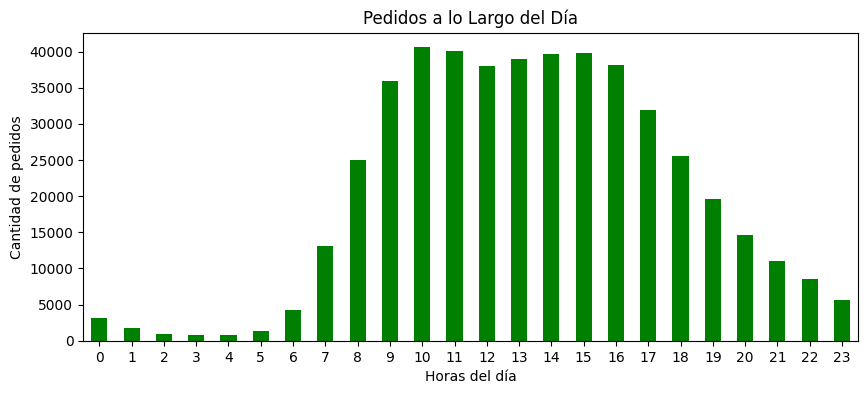

In [487]:
intacart_hours_count = df_instacart_orders.groupby("order_hour_of_day")["user_id"].count() # Agrupo ya que la gráfica de barras espera que cada categoría en x sea única.

intacart_hours_count.plot(kind="bar",
                       title="Pedidos a lo Largo del Día",
                       xlabel="Horas del día",
                       ylabel="Cantidad de pedidos",
                       color="green",
                       figsize=[10,4],
                       rot=0)
plt.show()

Conclusiones:

El anterior resultado nos muestra que la mayor demanda de pedidos es entre las 9 a.m. y 5 p.m. Esto sigue a la intuición ya que en ese horario es cuando las personas se encuentran mayormente activas durante el día, están ocupadas y realizan el super en línea o piden comida preparada para consumo.

### ¿Qué día de la semana compran víveres las personas?

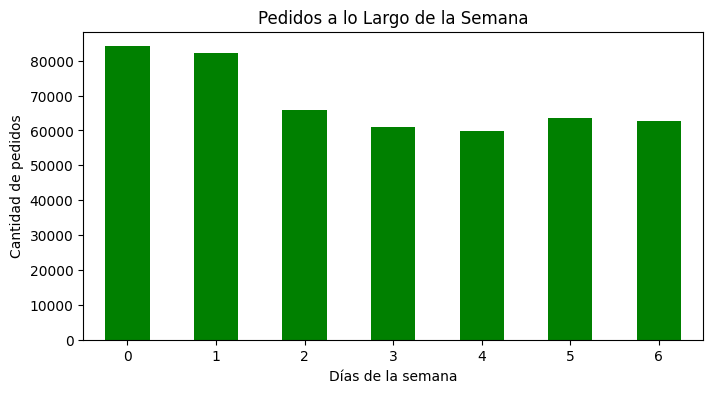

In [488]:
intacart_dow_count = df_instacart_orders.groupby("order_dow")["user_id"].count() # Agrupo ya que la gráfica de barras espera que cada categoría en x sea única.

intacart_dow_count.plot(kind="bar",
                       title="Pedidos a lo Largo de la Semana",
                       xlabel="Días de la semana",
                       ylabel="Cantidad de pedidos",
                       color="green",
                       figsize=[8,4],
                       rot=0)
plt.show()

Conclusiones:

Los usuarios realizan más pedidos los domingos y lunes, los días restantes son muy parecidos y no muy lejanos al top.

### ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

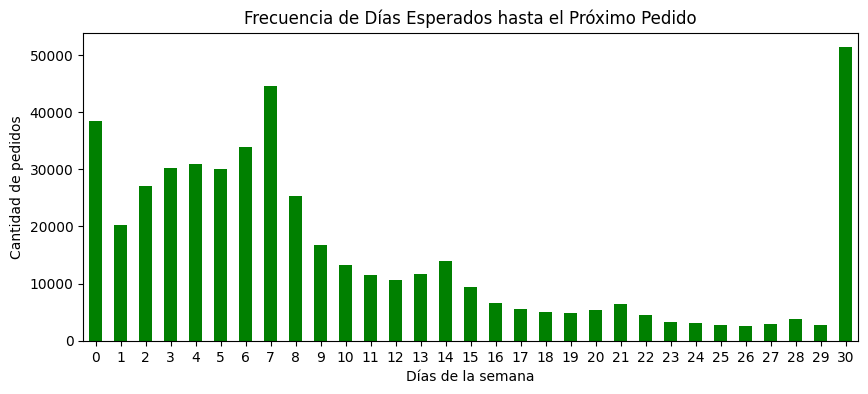

La mayor cantidad de pedidos se hacen después de esperar 30 días, mientras que la menor esperan 26 días.


In [489]:
instacart_days_order = df_instacart_orders.groupby("days_since_prior_order")["days_since_prior_order"].count() # Del último filtro, agrupo y cuento los días transcurridos desde que se hizo el último pedido, es decir, el primero.

instacart_days_order.plot(kind="bar",
                       title="Frecuencia de Días Esperados hasta el Próximo Pedido",
                       xlabel="Días de la semana",
                       ylabel="Cantidad de pedidos",
                       color="green",
                       figsize=[10,4],
                       rot=0)
plt.show()

min_instacart_days_order = instacart_days_order.idxmin() # Obtengo el ínidce con el valor contado mínimo. 
max_instacart_days_order = instacart_days_order.idxmax() # Obtengo el ínidce con el valor contado máximo.

print(f"La mayor cantidad de pedidos se hacen después de esperar {max_instacart_days_order} días, mientras que la menor esperan {min_instacart_days_order} días.")

Conclusiones:

Revisando la gráfica así como los mínimos y máximos, se puede notar que el top 3 de los días que más esperan los usuarios para realizar su próximo pedido son 0, 7 y 30. El 0 se identifica cuando los usuarios realizan su primer pedido más los que acumulen ese mismo día, 7 y 30 se puede interpretar que la gente suele comprar sus despensas semanal o mensual.

Casi todos los mínimos se situan entre los días 8 y 29, esto junto con lo anterior, nos puede decir que la gente suele volver a comprar sin esperar más de una semana o bien, cada mes.

### ¿Existen diferencias entre los pedidos a lo largo del miércoles y sábados?

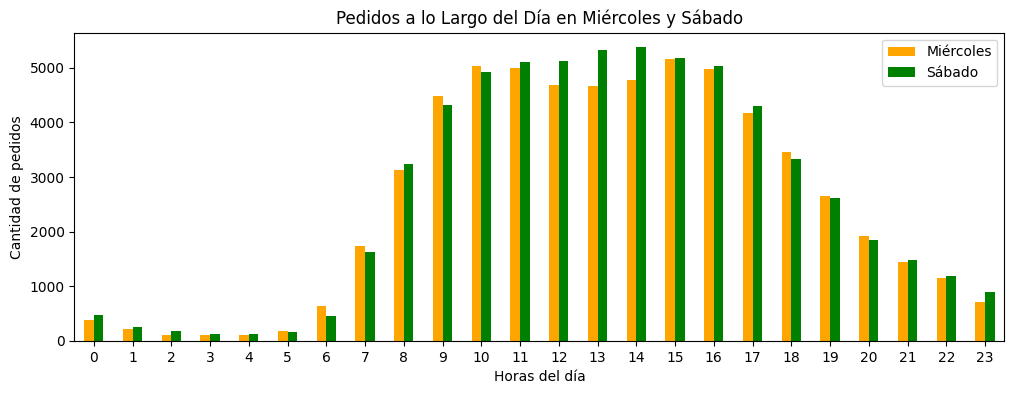

El total de órdenes en miércoles son 60,897, mientras que el total en sábado son 62,649, o bien, miércoles es el 97.2% de los pedidos del sábado.


In [490]:
# Crearé una tabla dinámica para concentrar solamente el conteo de los pedidos en las diferentes horas de los 7 días. 
pivot_days_hour = df_instacart_orders.pivot_table(index="order_hour_of_day",
                                                columns="order_dow",
                                                values="order_id",
                                                aggfunc="count")

pivot_days_hour_3_6 = pivot_days_hour[[3,6]] # Filtro a miércoles y sábado ya que son los únicos días que requiero comparar.

pivot_days_hour_3_6.plot(kind="bar",
                       title="Pedidos a lo Largo del Día en Miércoles y Sábado",
                       xlabel="Horas del día",
                       ylabel="Cantidad de pedidos",
                       color=["orange","green"],
                       figsize=[12,4],
                       rot=0)

plt.legend(["Miércoles","Sábado"]) #Renombro leyenda.
plt.show()

day_3_orders = pivot_days_hour_3_6[3].sum()
day_6_orders = pivot_days_hour_3_6[6].sum()
percentage_3_6 = (day_3_orders/day_6_orders)*100

print(f"El total de órdenes en miércoles son {day_3_orders:,}, mientras que el total en sábado son {day_6_orders:,}, o bien, miércoles es el {percentage_3_6:.1f}% de los pedidos del sábado.")

Conclusiones:

Visualizando la distribución de los pedidos en miércoles y sábado a lo largo de las horas del día, notamos que cada hora es muy parecida entre ambos días, incluso el número total de pedidos difiere por solo 2.8%. Además, se de esta semejanza, la distribución se asemeja también a la vista mostrada en el punto 7.2, donde se consideran todos los días de la semana.

### ¿Cuál es el comportamiento para el número de pedidos por cliente?

order_number
1      28817
2      28633
3      28685
4      28703
5      25661
       ...  
96       220
97       221
98       191
99       169
100      194
Name: order_id, Length: 100, dtype: int64


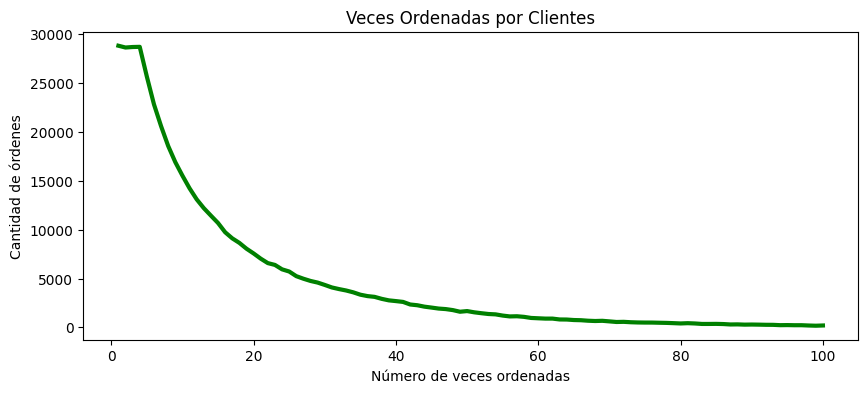

In [491]:
instacart_user_number = df_instacart_orders.groupby("order_number")["order_id"].count() # Cuento los pedidos hechos por el número de veces que los clientes han comprado.

print(instacart_user_number)

instacart_user_number.plot(title="Veces Ordenadas por Clientes",
                       xlabel="Número de veces ordenadas",
                       ylabel="Cantidad de órdenes",
                       color="green",
                       linewidth=3,
                       figsize=[10,4],
                       rot=0)
plt.show()

Conclusiones:

La anterior gráfica muestra la cantidad de veces que los clientes realizan pedidos, cabe destacar que de 1 a 4 veces son las más numerosas y muy semejantes, a partir de la 5 y hasta la 100 los pedidos caen considerablemente.

### ¿Cuáles son los 20 productos más populares?

Los 20 productos más comprados son:
    product_id              product_name  unit_sales
0        24852                    banana       66050
1        13176    bag of organic bananas       53297
2        21137      organic strawberries       37039
3        21903      organic baby spinach       33971
4        47209      organic hass avocado       29773
5        47766           organic avocado       24689
6        47626               large lemon       21495
7        16797              strawberries       20018
8        26209                     limes       19690
9        27845        organic whole milk       19600
10       27966       organic raspberries       19197
11       22935      organic yellow onion       15898
12       24964            organic garlic       15292
13       45007          organic zucchini       14584
14       39275       organic blueberries       13879
15       49683            cucumber kirby       13675
16       28204        organic fuji apple       12544
17        

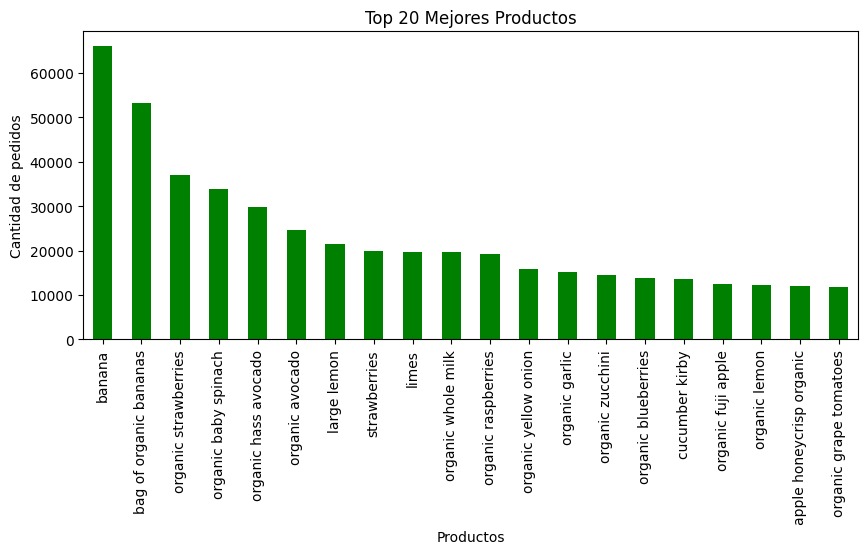

In [492]:
# Mi plan es crear dos DataFrames:
# 1. Un DataFrame con el top de productos, ordenados por sus ventas.
# 2. Otro DataFrame con solo el 'id' y el 'nombre' de los productos.
# Luego, uniré estos dos DataFrames usando el método merge() para crear un nuevo DataFrame que contenga solo tres columnas: 'id', 'nombre' y 'ventas'.
# Una vez conseguido, lo limitaré a los 20 productos más vendidos.
# Finalmente, graficaré los resultados para visualizar el top 20 de productos en términos de ventas.

top_products = df_order_products["product_id"].value_counts().sort_values(ascending=False) # Creo el top de los productos y los ordeno.
df_top_products = top_products.reset_index() # El series resultante de arriba lo transformo a df.
df_top_products.columns = ["product_id", "unit_sales"] # Renombro las columnas de nuevo df ya por defecto, una se llamaba index.

df_id_name_products = df_products[["product_id","product_name"]] # Ahora creo el segundo df.

df_merge_top_products = df_top_products.merge(df_id_name_products, on="product_id", how="left") # Uno los dos nuevos df.
df_merge_top_products = df_merge_top_products.reindex(columns=["product_id", "product_name", "unit_sales"]) # Reordeno las columnas para mejor presentación.

df_top_20_products = df_merge_top_products.iloc[0:20] # Creo df final acotanto a los 20 primeros de la lista, como desde el inicio se ordenó, estos son el top 20. 
print("Los 20 productos más comprados son:")
print(df_top_20_products)

df_top_20_products.plot(kind="bar",
                       x="product_name",
                       y="unit_sales",
                       title="Top 20 Mejores Productos",
                       xlabel="Productos",
                       ylabel="Cantidad de pedidos",
                       color="green",
                       legend=False,
                       figsize=[10,4])
plt.show()

Los descubrimientos son:

1. El producto más vendido son los plátanos.
2. 19 productos del top 20 son frutas o verduras.
3. 14 productos del top 20 son orgánicos.
4. El top 1 es 2 veces más grande que el top 3, casi tres veces más que el top 5 y 6 veces más grande que el top 20. Esto nos permite dimensionar qué tan grande es el producto más vendido.

### ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

    purchased_products  orders
0                    1   21847
1                    2   26292
2                    3   29046
3                    4   31054
4                    5   31923
..                 ...     ...
85                  98       1
86                 104       1
87                 108       1
88                 115       1
89                 127       1

[90 rows x 2 columns]

Efectivamente, la cantidad de pedidos únicos por 450046, es igual a la suma de las órdenes del anterior DataFrame con 450046 también.

El número de artículos comprados con más pedidos es:  4


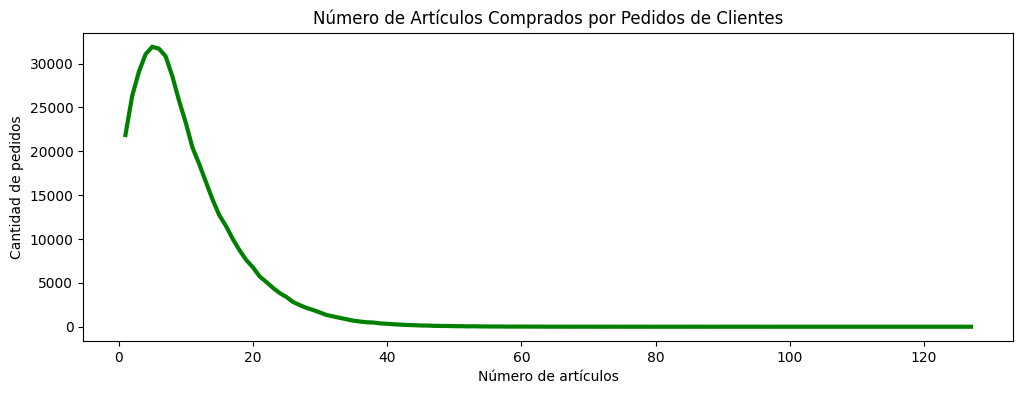

In [493]:
# El plan es aprovechar que cada fila en 'order_products' representa un artículo de un pedido.
# Por lo tanto, un mismo número de pedido aparecerá tantas veces como artículos se hayan comprado en ese pedido.
# Es decir, si el pedido X compró N artículos, el número de pedido X se repetirá N veces.
# Para calcular cuántos artículos se compraron en cada pedido, usaré .value_counts() en la columna de pedidos.
# Esto me generará un Series donde los índices serán los números de pedido, y los valores representarán la cantidad de artículos comprados en cada uno.
# Luego, aplicaré un segundo .value_counts() sobre este Series para contar cuántas veces aparece cada cantidad de artículos comprados.
# Este segundo Series representará cuántos pedidos compraron exactamente N artículos.
# Una comprobación del resultado será que el conteo de pedidos únicos deberá ser igual a la suma total de los pedidos del último Series.
# Finalmente, convertiré este Series en un DataFrame para poder graficar la distribución de la cantidad de artículos comprados por pedido.

value_counts_orders = df_order_products["order_id"].value_counts().sort_values(ascending=False) # Creo primer Series y lo ordeno para de una vez conocer máximo de artículos comprados.
total_unique_orders = df_order_products["order_id"].nunique() # Cuantifico la primera parte de mi comprobación.

value_counts_products = value_counts_orders.value_counts().sort_index() # Creo segundo Series y ordeno por el Index para que mi futura gráfica esté ordenada en el eje x.
total_sum_orders = value_counts_products.sum() # Cuantifico la segunda parte de mi comprobación.

df_products_orders = (
    value_counts_products
    .rename("orders")
    .reset_index()
) # Convierto el Series en DataFrame.
df_products_orders.columns = ["purchased_products", "orders"] # Renombro las columnas a nombres adecuados.

print(df_products_orders)
print()
print(f"Efectivamente, la cantidad de pedidos únicos por {total_unique_orders}, es igual a la suma de las órdenes del anterior DataFrame con {total_sum_orders} también.")
print()
print("El número de artículos comprados con más pedidos es: ", df_products_orders["orders"].idxmax()) # Consigo el número de artículo con más pedidos.

df_products_orders.plot(title="Número de Artículos Comprados por Pedidos de Clientes",
                        x="purchased_products",
                        y="orders",
                        xlabel="Número de artículos",
                        ylabel="Cantidad de pedidos",
                        color="green",
                        linewidth=3,
                        legend=False,
                        figsize=[12,4],
                        rot=0)
plt.show()

Los puntos a destacar son:

1. 4 en la cantidad de artículos que suele comprarse más en los pedidos.
2. A partir de 5 artículos la cantidad de pedidos que los compra comienza a caer considerablemente hasta llegar al máximo de 127 artículos.
3. Mañana sigo jeje.

### ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia?

Los 20 productos más comprados que vuelven a pedirse son:
    product_id              product_name  reordered
0        24852                    banana      55763
1        13176    bag of organic bananas      44450
2        21137      organic strawberries      28639
3        21903      organic baby spinach      26233
4        47209      organic hass avocado      23629
5        47766           organic avocado      18743
6        27845        organic whole milk      16251
7        47626               large lemon      15044
8        27966       organic raspberries      14748
9        16797              strawberries      13945
10       26209                     limes      13327
11       22935      organic yellow onion      11145
12       24964            organic garlic      10411
13       45007          organic zucchini      10076
14       49683            cucumber kirby       9538
15       28204        organic fuji apple       8989
16        8277  apple honeycrisp organic       8836
17    

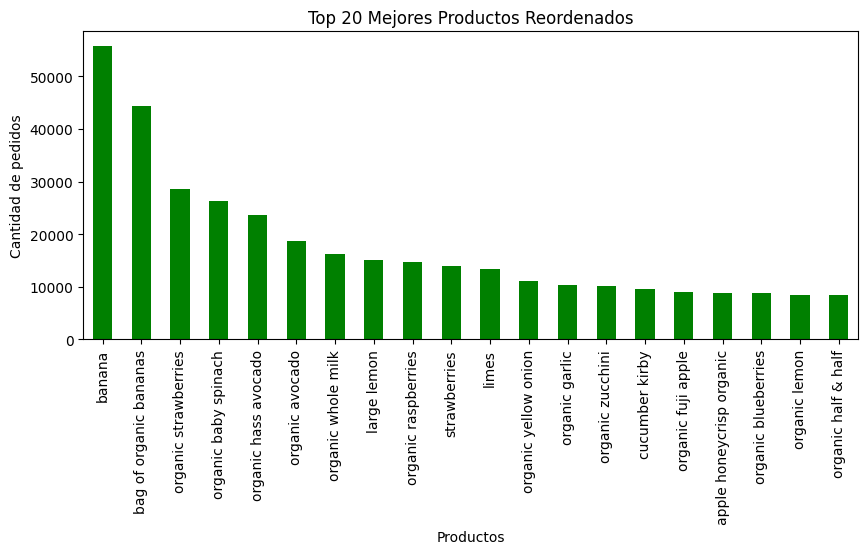

In [494]:
# Reusaré el código del punto B3 ya que la estrategia para responder esta pregunta es muy parecida, incluso reusaré un poco del código ahí escrito.

top_products_reordered = df_order_products[df_order_products["reordered"]==1]["product_id"].value_counts().sort_values(ascending=False) # Filtro df con los reordenados, creo el top de los productos y los ordeno.
df_top_products_reordered = top_products_reordered.reset_index() # El series resultante de arriba lo transformo a df.
df_top_products_reordered.columns = ["product_id", "reordered"] # Renombro las columnas.

df_merge_top_products_reordered = df_top_products_reordered.merge(df_id_name_products, on="product_id", how="left") # Uno el nuevo df con el creado en B3 que contiene id y nombres de los productos.
df_merge_top_products_reordered = df_merge_top_products_reordered.reindex(columns=["product_id", "product_name", "reordered"]) # Reordeno las columnas para mejor presentación.

df_merge_top_20_products_reordered = df_merge_top_products_reordered.iloc[0:20] # Creo df final acotanto a los 20 primeros de la lista, como desde el inicio se ordenó, estos son el top 20. 
print("Los 20 productos más comprados que vuelven a pedirse son:")
print(df_merge_top_20_products_reordered)

df_merge_top_20_products_reordered.plot(kind="bar",
                                        x="product_name",
                                        y="reordered",
                                        title="Top 20 Mejores Productos Reordenados",
                                        xlabel="Productos",
                                        ylabel="Cantidad de pedidos",
                                        color="green",
                                        legend=False,
                                        figsize=[10,4])
plt.show()

Conclusiones:

Los descubrimientos de este top muy parecidos al top 20 de productos más vendidos, en escencia:

1. El producto más vendido reordenado siguen siendo los plátanos.
2. La gran mayoria siguen siendo frutas o verduras.
3. Seguimos teniendo 14 productos orgánicos.

En resumen, el top 20 de productos reordenados más vendidos no difiere mucho en cantidad de pedidos y se mantiene casi la totalidad de los mismos productos que el top 20 más vendido.

### Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

    product_id                          product_name  total_orders  \
0        24852                                banana         66050   
1        13176                bag of organic bananas         53297   
4        47209                  organic hass avocado         29773   
2        21137                  organic strawberries         37039   
3        21903                  organic baby spinach         33971   
5        47766                       organic avocado         24689   
6        47626                           large lemon         21495   
7        16797                          strawberries         20018   
8        26209                                 limes         19690   
25       19057  organic large extra fancy fuji apple         10651   

    total_reorders  reorder_rate  
0            55763      0.844254  
1            44450      0.834006  
4            23629      0.793639  
2            28639      0.773212  
3            26233      0.772217  
5            18743 

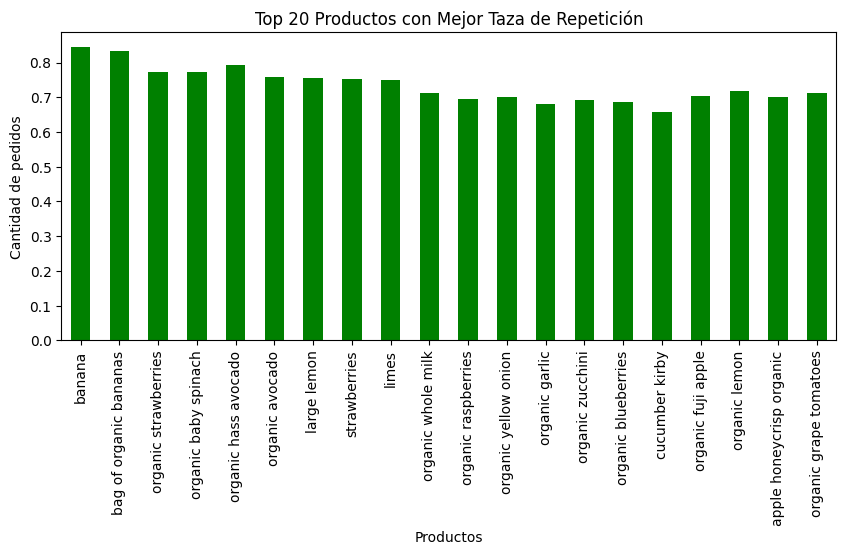

In [495]:
# Para dar solución:
# 1. Usaré los DataFrames de B3 (top productos ordenados) y C2 (top productos reordenados).
# 2. Los concatenaré en un nuevo DataFrame que incluya ID, nombre del producto y los datos necesarios para calcular la tasa.
# 3. Revisaré el DataFrame para tratar nulos y asegurar que los tipos de datos sean correctos.
# 4. Añadiré una columna que calcule la tasa de repetición.

df_reorder_rate = pd.concat([df_merge_top_products, df_merge_top_products_reordered["reordered"]], axis="columns") # Concateno df's existentes. 
df_reorder_rate.columns = ["product_id", "product_name", "total_orders", "total_reorders"] # Renombro con títulos más adecuados.

df_reorder_rate["product_name"] = df_reorder_rate["product_name"].fillna("Unknow") # Ya se había establecido que los nombres nulos pertenecían al departamento desaparecido y se nombraron "Unkonw".
df_reorder_rate["total_reorders"] = df_reorder_rate["total_reorders"].fillna(0) # NaN significa que los productos no tuvieron recompra, por esto pongamos 0.
#print(df_reorder_rate.isna().sum()) # Confirmo cambios.

#df_reorder_rate.info() # Noté que al concatenar, la columna "total_reorders" era float, revisé los tipos para determinar qué hacer.
df_reorder_rate["total_reorders"] = df_reorder_rate["total_reorders"].astype("Int64") # Cambio de tipo solo una columna.

df_reorder_rate["reorder_rate"] = df_reorder_rate["total_reorders"]/df_reorder_rate["total_orders"] # Creo nueva columna que calcula la taza.

print(df_reorder_rate.sort_values("reorder_rate", ascending=False).head(10)) # Visualizo el top 10 con la mayor taza.

# Como extra, grafico para visualizar mejor el resultado.
df_reorder_rate.iloc[0:20].plot(kind="bar",
                                x="product_name",
                                y="reorder_rate",
                                title="Top 20 Productos con Mejor Taza de Repetición",
                                xlabel="Productos",
                                ylabel="Cantidad de pedidos",
                                color="green",
                                legend=False,
                                figsize=[10,4])
plt.show()

Conclusiones:

La tasa de repetición es un indicador que nos ayuda a identificar la fidelidad o satisfacción de los clientes a los productos, en el anterior resultado, vemos como el top 20 de cuenta con tazas muy altas, superiores al 70%, y los artículos han sido los mismos que hemos visto encabezando los demás top.

### Para cada cliente, ¿qué proporción de sus productos ya los había comprado antes?

In [496]:
# Para dar solución, seguiré el siente plan:
# 1. Uniré la los df order_products e instacart_orders acotando a solo lo que necesito.
# 2. Calcularé la cantidad de productos reordenados y no reordenados por cliente.
# 3. Calcularé la tasa de repetición para cada cliente.

df_merge_products_instacart = df_order_products[["order_id", "reordered"]].merge(df_instacart_orders[["user_id","order_id"]], on="order_id", how="left") # Uno solamente las columnas imporatntes de los df que me relacionan los usuarios con las órdenes y si el producto fue pedido antes.

df_reorder_rate = df_merge_products_instacart.pivot_table(index="user_id", columns="reordered", aggfunc="size", fill_value=0) # Creo un df con los clientes únicos, cuántos productos ordenó sin haber ordenado antes y cuántos reordenados.
df_reorder_rate.columns = ["products_no_reordered", "products_reordered"] # Renombro coherentemente las columnas.

# Como método de comprobación, el total de órdenes globales debe ser igual a la suma de las órdens no ordenadas antes
# más las reordenadas, esto funciona ya que no hay nulos en "reordered".
#print(df_order_products["order_id"].count() == ( df_reorder_rate["products_no_reordered"].sum() + df_reorder_rate["products_reordered"].sum() ))

df_reorder_rate["reorders_rate"] = (df_reorder_rate["products_reordered"] / ( df_reorder_rate["products_reordered"] + df_reorder_rate["products_no_reordered"] )).round(2) # Creo nueva columna con el cálculo de la tasa.
print(df_reorder_rate.sort_values("reorders_rate", ascending=False)) # Visualizo la tabla final.

         products_no_reordered  products_reordered  reorders_rate
user_id                                                          
22                           0                   6            1.0
18952                        0                   3            1.0
18977                        0                   3            1.0
196365                       0                   1            1.0
136025                       0                   1            1.0
...                        ...                 ...            ...
206175                       7                   0            0.0
206167                       8                   0            0.0
206153                       6                   0            0.0
177312                       7                   0            0.0
153492                       6                   0            0.0

[149626 rows x 3 columns]


In [497]:
# En este punto considero que ya he conseguido lo que el ejercicio pide, sin embargo,
# noto que hace falta trabajar un poco más este resultado para visualizar las tasas y entenderlas mejor.
# Mi plan es segmentar o categorizar las tasas para gráficamente visualizar las densidades.

bins = [-0.01, 0, 0.33, 0.66, 0.99, 1] # Determino la segmentación, convenientemente ya he redondeado a 2 decimales para no lidiar con valores tipo 0.9999999.
labels = ["Tasa nula, 0%", "Tasa baja, 1%-33%", "Tasa media, 34%-66%", "Tasa alta, 67%-99%", "Tasa perfecta, 100%"] # Nombro cada categoría.
df_reorder_rate["reorders_category"] = pd.cut(df_reorder_rate["reorders_rate"], bins=bins, labels=labels) # Creo nueva columna en el df con la categoría a la que pertenece.
print(df_reorder_rate.sort_values("reorders_rate", ascending=False)) # Visualizo el df actualizado.

         products_no_reordered  products_reordered  reorders_rate  \
user_id                                                             
22                           0                   6            1.0   
18952                        0                   3            1.0   
18977                        0                   3            1.0   
196365                       0                   1            1.0   
136025                       0                   1            1.0   
...                        ...                 ...            ...   
206175                       7                   0            0.0   
206167                       8                   0            0.0   
206153                       6                   0            0.0   
177312                       7                   0            0.0   
153492                       6                   0            0.0   

           reorders_category  
user_id                       
22       Tasa perfecta, 100%  
18952    

reorders_category
Tasa nula, 0%          16635
Tasa baja, 1%-33%      30840
Tasa media, 34%-66%    52381
Tasa alta, 67%-99%     41668
Tasa perfecta, 100%     8102
Name: count, dtype: int64


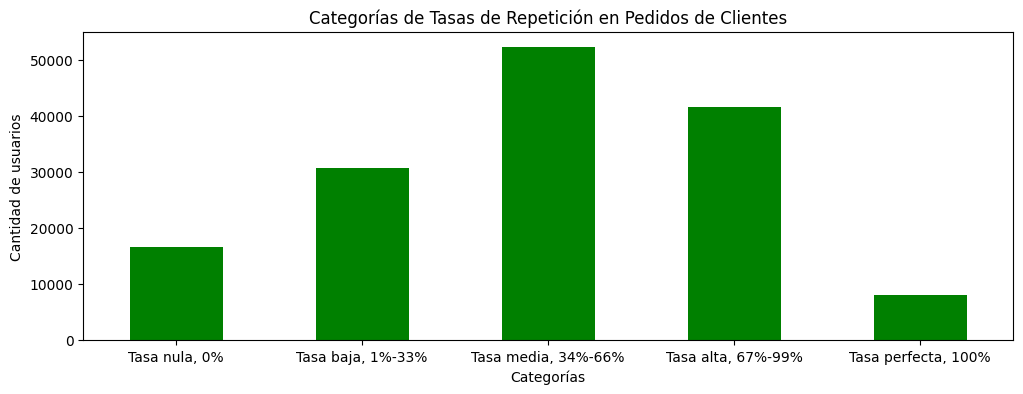

In [498]:
# Ahora graficaré cuántos usuarios están en cada categoría.

values_reorders_category = df_reorder_rate["reorders_category"].value_counts() # La última columna creada será la que se graficará.
values_reorders_category = values_reorders_category[labels] # Requiero que se grafique ordenado, tal como se definieron las etiquetas.

# Requiero antes comprobar que la segmentación contabilice todas las tasas,
# así, el largo del último df debe ser igual que la suma de lo contabilizado en cada categoría.
#print(len(df_reorder_rate) == values_reorders_category.sum())

# Además, me es importante que la categoría del 0% y la del 100% esté bien contada.
# El siguiente print me muestra cuántos usuarios tienes taza nula y perfecta.
#print(df_reorder_rate["reorders_rate"].value_counts().sort_index()) 

print(values_reorders_category) # Efectivamente, ambas tasas concuerdan con el número de usuarios correcto y está listo para graficar.

values_reorders_category.plot(kind="bar",
                       title="Categorías de Tasas de Repetición en Pedidos de Clientes",
                       xlabel="Categorías",
                       ylabel="Cantidad de usuarios",
                       color="green",
                       linewidth=3,
                       legend=False,
                       figsize=[12,4],
                       rot=0)
plt.show()

Conclusiones:

El resultado obtenido nos muestra la distribución de las tasas de repetición de los clientes de forma categórica, donde podemos ver:

1. La tasa nula representa el 11% de los clientes, mismos que que vale la pena investigar si sus compras fueron únicas, algúnos productos específicos o no vuelven por alguna particularidad.
2. La tasa media y alta son las más grandes, representando juntos el 62% de los clientes, mostrando una alta satisfacción y fidelidad a los productos que recompran aunque aún destinan una parte de su carrito en nuevos productos.
3. La tasa perfecta se encuentra con el 5% de los clientes, esto significa que han elegido a Instacart como su lugar de preferencia para sus compras monótonas. Valdría el esfuerzo revisar el ticket promedio de estos clientes.

### ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

Los 20 productos más comprados que fueron agregados primero al carrito en los pedidos son:
    product_id                 product_name  first_add_to_cart_order
0        24852                       banana                    15562
1        13176       bag of organic bananas                    11026
2        27845           organic whole milk                     4363
3        21137         organic strawberries                     3946
4        47209         organic hass avocado                     3390
5        21903         organic baby spinach                     3336
6        47766              organic avocado                     3044
7        19660                 spring water                     2336
8        16797                 strawberries                     2308
9        27966          organic raspberries                     2024
10       44632   sparkling water grapefruit                     1914
11       49235          organic half & half                     1797
12       476

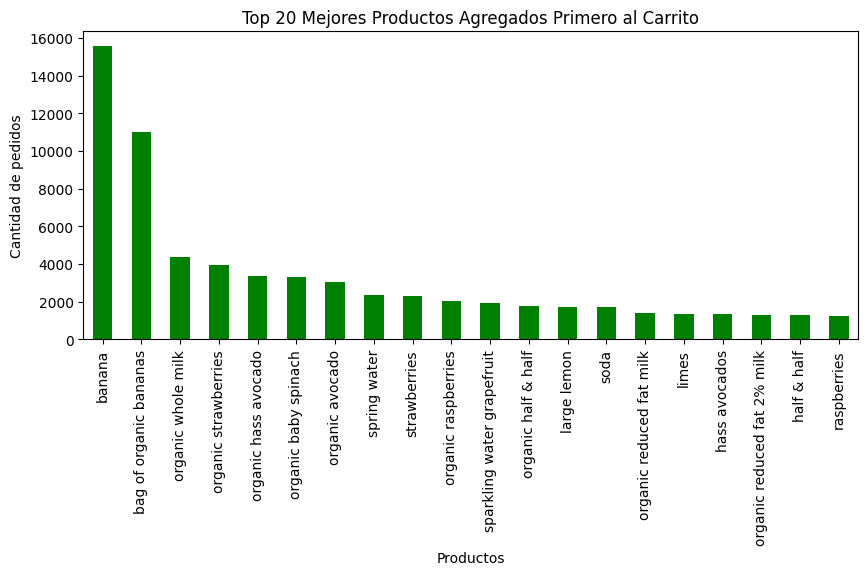

In [499]:
# Reusaré el código del punto C2 ya que la estrategia para responder esta pregunta es muy parecida, incluso reusaré un poco del código ahí escrito.

top_products_add_1 = df_order_products[df_order_products["add_to_cart_order"]==1]["product_id"].value_counts().sort_values(ascending=False) # Filtro df cuya valor en la columna add_to_cart_order es 1, creo el top de los productos y los ordeno.
df_top_products_add_1 = top_products_add_1.reset_index() # El series resultante de arriba lo transformo a df.
df_top_products_add_1.columns = ["product_id", "first_add_to_cart_order"] # Renombro las columnas.

df_merge_top_products_add_1 = df_top_products_add_1.merge(df_id_name_products, on="product_id", how="left") # Uno el nuevo df con el creado en B3 que contiene id y nombres de los productos.
df_merge_top_products_add_1 = df_merge_top_products_add_1.reindex(columns=["product_id", "product_name", "first_add_to_cart_order"]) # Reordeno las columnas para mejor presentación.

df_merge_top_20_products_add_1 = df_merge_top_products_add_1.iloc[0:20] # Creo df final acotanto a los 20 primeros de la lista, como desde el inicio se ordenó, estos son el top 20. 
print("Los 20 productos más comprados que fueron agregados primero al carrito en los pedidos son:")
print(df_merge_top_20_products_add_1)

df_merge_top_20_products_add_1.plot(kind="bar",
                                    x="product_name",
                                    y="first_add_to_cart_order",
                                    title="Top 20 Mejores Productos Agregados Primero al Carrito",
                                    xlabel="Productos",
                                    ylabel="Cantidad de pedidos",
                                    color="green",
                                    legend=False,
                                    figsize=[10,4])
plt.show()

Conclusiones:

En este último top podemos destacar que muchas frutas y verduras orgánicas se mantienen en la lista al igual que los anteriores tops, pero una gran diferencia es que los primeros dos productos duplican al tercero y aún más a sus consecutivos.

### Conclusion general del proyecto

El análisis realizado sobre la plataforma Instacart revela patrones importantes en los hábitos de compra de sus usuarios, los más relevantes son:

- Las horas pico para realizar pedidos se concentran entre las 9 a.m. y 5 p.m., mientras que los días con más demanda son los domingos y lunes.
- Gran proporción de los usuarios repiten sus compras cada 1, 7 o 30 días, indicando que los clientes suelen hacer compras diarias, semanales o mensuales.
- Los productos más vendidos y más frecuentemente reordenados son principalmente frutas y verduras, con los plátanos liderando de manera significativa.
- La tasa de repetición de los clientes muestra que un 62% tiene una fidelidad moderada o alta a los productos que han comprado anteriormente.

Estos hallazgos sugieren que Instacart ha captado un público fiel a productos frescos y orgánicos, y hay oportunidades para fomentar la recompra entre aquellos clientes que aún no han desarrollado una alta tasa de repetición.